# Gradient Descent: Manual Fit Checked Against scikit-learn

This notebook verifies a manual gradient-descent implementation against
scikit-learn on a deliberately simplified version of the project problem. Both
methods fit the same standardized log-MRT feature to the same training rows.
The simplified fit makes the optimization path visible and gives a trusted
numerical result to compare against.

This is not the production training path. Only the 331 training rows are used,
the protected holdout is not opened, and the selected histogram boosting
model is unchanged.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

from house_prices import config
from house_prices.data import load_dataset
from house_prices.train import split_data

df = load_dataset()
X_train, _, y_train, _ = split_data(df)
x_raw = np.log10(X_train["mrt_distance_m"].to_numpy())
x_mean, x_std = x_raw.mean(), x_raw.std()
x = (x_raw - x_mean) / x_std
y = y_train.to_numpy()
print(f"Reference fit: {len(x)} training rows; protected holdout untouched")

Reference fit: 331 training rows; protected holdout untouched


## The objective being checked

The manual loop and `sklearn.linear_model.LinearRegression` receive the same
one-feature data. For the manual implementation, the prediction is
$\hat{y}=wx+b$ and the squared-error cost is
$J(w,b)=\frac{1}{2m}\sum(\hat{y}-y)^2$. Its partial derivatives are
$\frac{\partial J}{\partial w}=\frac{1}{m}\sum(\hat{y}-y)x$ and
$\frac{\partial J}{\partial b}=\frac{1}{m}\sum(\hat{y}-y)$.

Gradient descent reaches the minimum through repeated updates. scikit-learn's
linear-regression solver reaches the least-squares solution directly. Agreement
between them checks the manual cost, gradients and updates.

In [2]:
def compute_cost(x, y, w, b):
    errors = w * x + b - y
    return float(np.mean(errors**2) / 2)


def compute_gradient(x, y, w, b):
    errors = w * x + b - y
    return float(np.mean(errors * x)), float(np.mean(errors))


def gradient_descent(x, y, alpha, iterations, w=0.0, b=0.0):
    history = []
    for step in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w_next = w - alpha * dj_dw
        b_next = b - alpha * dj_db
        w, b = w_next, b_next
        history.append((step + 1, w, b, compute_cost(x, y, w, b)))
    return w, b, np.asarray(history)


w_gd, b_gd, good_path = gradient_descent(x, y, alpha=0.05, iterations=250)
_, _, slow_path = gradient_descent(x, y, alpha=0.005, iterations=250)
_, _, large_path = gradient_descent(x, y, alpha=2.10, iterations=30)

closed_form = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"manual GD:       w={w_gd:.4f}, b={b_gd:.4f}, cost={good_path[-1, 3]:.4f}")
print(f"sklearn optimum: w={closed_form.coef_[0]:.4f}, b={closed_form.intercept_:.4f}")
print(f"first gradient:  dJ/dw={compute_gradient(x, y, 0.0, 0.0)[0]:.4f}, "
      f"dJ/db={compute_gradient(x, y, 0.0, 0.0)[1]:.4f}")

manual GD:       w=-9.2234, b=37.6697, cost=40.7545
sklearn optimum: w=-9.2234, b=37.6698
first gradient:  dJ/dw=9.2234, dJ/db=-37.6698


For this check, standardizing the input makes the two directions of the cost
surface similarly scaled, so one learning rate can move efficiently in both.
Scaling does not change the fitted linear relationship; it changes the numerical
route to the optimum and the units in which the slope is expressed.

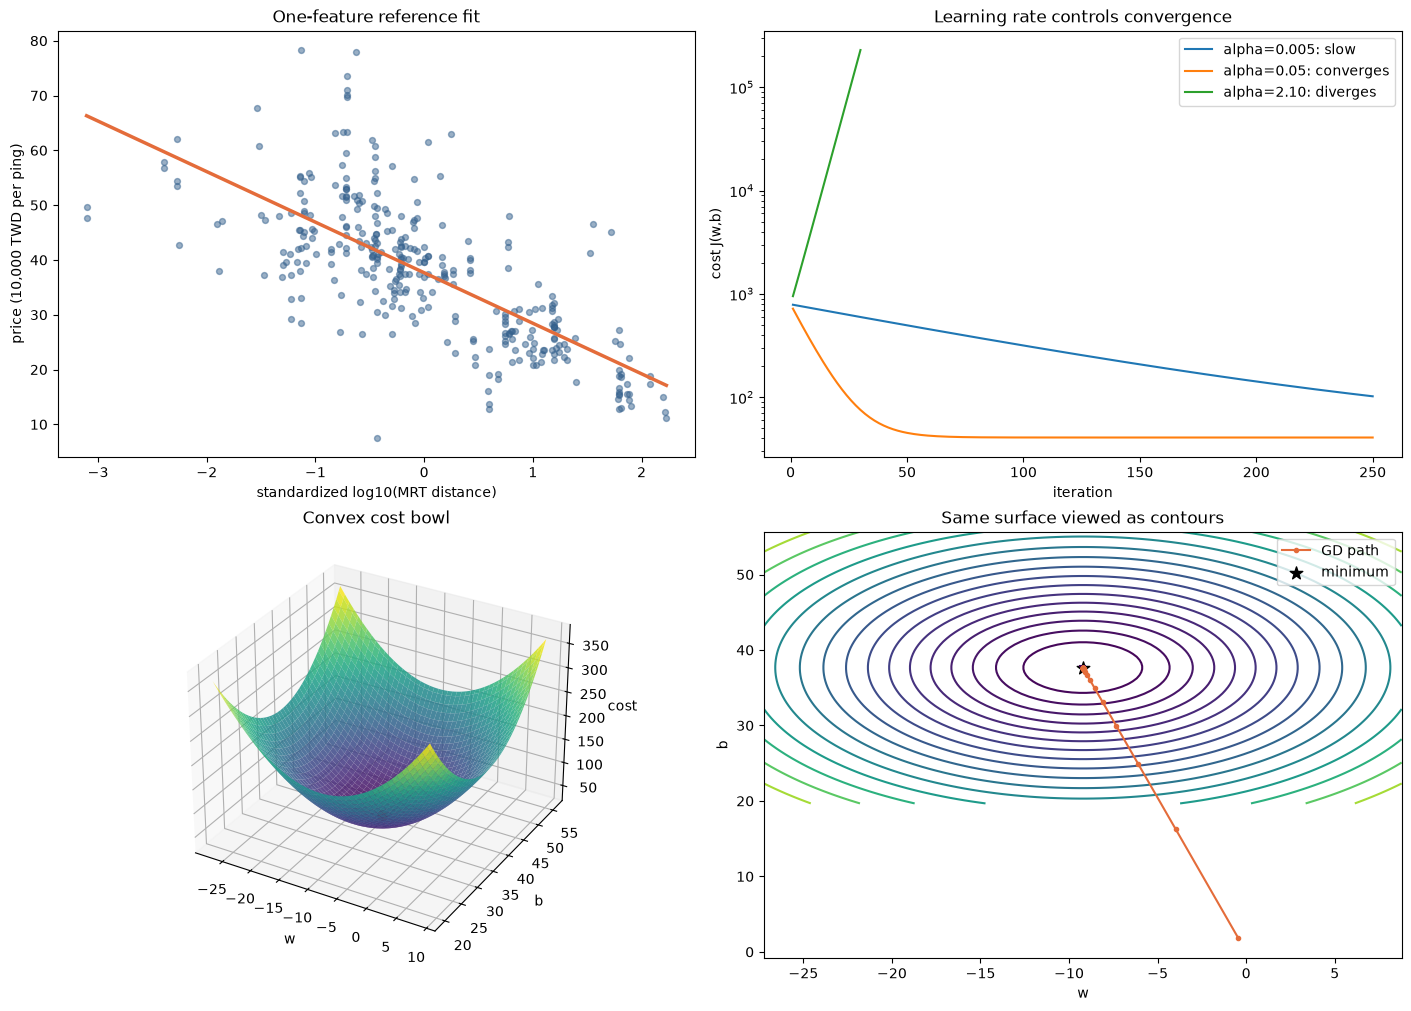

saved D:\Learning\Supervised Machine - Learning Regression and Classification\Labs\Use_case\house-price-predictor\docs\figures\gradient_descent_reference.png


In [3]:
w_star = float(closed_form.coef_[0])
b_star = float(closed_form.intercept_)
w_grid = np.linspace(w_star - 18, w_star + 18, 90)
b_grid = np.linspace(b_star - 18, b_star + 18, 90)
W, B = np.meshgrid(w_grid, b_grid)
J = np.array([[compute_cost(x, y, w, b) for w in w_grid] for b in b_grid])

fig = plt.figure(figsize=(14, 10), constrained_layout=True)
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x, y, s=18, alpha=0.5, color="#35618d")
x_line = np.linspace(x.min(), x.max(), 100)
ax1.plot(x_line, w_gd * x_line + b_gd, color="#e46c3a", linewidth=2.5)
ax1.set(title="One-feature reference fit", xlabel="standardized log10(MRT distance)",
        ylabel="price (10,000 TWD per ping)")

ax2 = fig.add_subplot(2, 2, 2)
ax2.semilogy(slow_path[:, 0], slow_path[:, 3], label="alpha=0.005: slow")
ax2.semilogy(good_path[:, 0], good_path[:, 3], label="alpha=0.05: converges")
ax2.semilogy(large_path[:, 0], large_path[:, 3], label="alpha=2.10: diverges")
ax2.set(title="Learning rate controls convergence", xlabel="iteration", ylabel="cost J(w,b)")
ax2.legend()

ax3 = fig.add_subplot(2, 2, 3, projection="3d")
ax3.plot_surface(W, B, J, cmap="viridis", alpha=0.85, linewidth=0)
ax3.scatter([w_star], [b_star], [compute_cost(x, y, w_star, b_star)],
            color="#e46c3a", s=45, label="minimum")
ax3.set(title="Convex cost bowl", xlabel="w", ylabel="b", zlabel="cost")

ax4 = fig.add_subplot(2, 2, 4)
levels = np.geomspace(max(J.min(), 1e-3), J.max(), 18)
ax4.contour(W, B, J, levels=levels, cmap="viridis")
path = good_path[::10]
ax4.plot(path[:, 1], path[:, 2], "o-", color="#e46c3a", markersize=3, label="GD path")
ax4.scatter([w_star], [b_star], color="black", marker="*", s=90, label="minimum")
ax4.set(title="Same surface viewed as contours", xlabel="w", ylabel="b")
ax4.legend()

figure_path = config.REPORTS_DIR / "gradient_descent_reference.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"saved {figure_path}")

## Result: the manual fit reproduces scikit-learn

Both implementations fit the same standardized `log10(mrt_distance_m)` feature
to the same 331 training rows.

| implementation | $w$ | $b$ |
|---|---:|---:|
| manual gradient descent | -9.2234 | 37.6697 |
| scikit-learn `LinearRegression` | -9.2234 | 37.6698 |

The displayed parameters agree within 0.0001. This is the key verification:
the hand-written gradients and update loop converge to effectively the same
least-squares solution as the trusted library implementation.

### What these values mean for this data

- Because the input is standardized log-distance, $w=-9.2234$ means that a
  one-standard-deviation increase in log MRT distance is associated with a
  decrease of about 9.22 target units, or about 92,200 TWD per ping, in this
  one-feature fit. This is an association, not a causal claim.
- $b=37.6698$ is the fitted price when standardized log-distance is zero, which
  is the mean log-distance in these training rows: about 376,700 TWD per ping.
- The final cost 40.7545 is half the mean squared error by definition here. It
  corresponds to a training RMSE of about 9.03 target units, or 90,300 TWD per
  ping. It is not a grouped-CV or protected-holdout score.

### Connection to the modeling notebook

[`02_modeling.ipynb`](02_modeling.ipynb) compares complete candidate pipelines
using grouped cross-validation. Its linear candidates use scikit-learn, while
the frozen production candidate is histogram boosting. This notebook
has a narrower purpose: it checks one optimization method on a one-feature linear
problem. It neither reproduces the full linear candidate nor trains or justifies
the deployed tree ensemble.